#  Yelp Review Sentiment — Interactive Colab


In [ ]:
#@title  Setup (run once)
import sys
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    from google.colab import output
    output.enable_custom_widget_manager()
try:
    import ipywidgets as widgets
except Exception:
    !pip -q install ipywidgets
    import ipywidgets as widgets
try:
    import sklearn, pandas, numpy, matplotlib, joblib
except Exception:
    !pip -q install scikit-learn pandas numpy matplotlib joblib
    import sklearn, pandas, numpy, matplotlib, joblib
from IPython.display import display, Markdown
display(Markdown('** Setup complete.**'))

**✅ Setup complete.**

## Reflection Capture Configuration (Google Sheets)

These settings send participants' reflection answers to a linked Google Sheet. Reflections are not echoed back in the notebook output.

**Setup:**
1. Create a Google Sheet and copy its ID.
2. Prefer a Google Cloud service account with access to the Sheet (share the Sheet with the service account email) and place its JSON key next to this notebook (e.g., `gcp_service_account.json`).
3. Set `SHEET_ID` and `WORKSHEET_NAME` below. If you cannot use a service account, set `USE_OAUTH=True` for an interactive login.


In [ ]:
# --- Reflection capture settings ---
SAVE_TO_SHEETS = True
SHEET_ID = "1xCPo4kBtYVbmivfZkfIuUysTl11uJsncVEj2xgbMsbg"            # paste your Google Sheet ID here
WORKSHEET_NAME = 'Reflections'  # tab name
SERVICE_ACCOUNT_JSON = 'gcp_service_account.json'
USE_OAUTH = False  # set True to use OAuth flow instead of service account

import datetime, os

def _get_gspread_client():
    try:
        import gspread
        if os.path.exists(SERVICE_ACCOUNT_JSON) and not USE_OAUTH:
            from google.oauth2.service_account import Credentials
            scopes = [
                'https://www.googleapis.com/auth/spreadsheets',
                'https://www.googleapis.com/auth/drive'
            ]
            creds = Credentials.from_service_account_file(SERVICE_ACCOUNT_JSON, scopes=scopes)
            return gspread.authorize(creds)
        elif USE_OAUTH:
            return gspread.oauth()
        else:
            raise RuntimeError('No credentials available. Provide service account JSON or set USE_OAUTH=True.')
    except Exception as e:
        print('Google Sheets client not configured:', e)
        return None

def _open_sheet(gc, sheet_id: str, worksheet: str):
    try:
        sh = gc.open_by_key(sheet_id)
        try:
            ws = sh.worksheet(worksheet)
        except Exception:
            ws = sh.add_worksheet(title=worksheet, rows=1000, cols=20)
        return ws
    except Exception as e:
        print('Unable to open sheet:', e)
        return None

def append_reflection_row(step_title: str, user_id: str, reflection_text: str):
    if not SAVE_TO_SHEETS or not SHEET_ID:
        return False, 'Saving disabled or SHEET_ID not set.'
    gc = _get_gspread_client()
    if gc is None:
        return False, 'No Google Sheets client.'
    ws = _open_sheet(gc, SHEET_ID, WORKSHEET_NAME)
    if ws is None:
        return False, 'Worksheet not available.'
    header = ['timestamp','user_id','step','reflection']
    try:
        existing = ws.get_all_values()
        if not existing or existing[0] != header:
            ws.clear()
            ws.append_row(header)
    except Exception:
        try:
            ws.append_row(header)
        except Exception:
            pass
    ts = datetime.datetime.utcnow().isoformat()
    try:
        ws.append_row([ts, user_id or 'anonymous', step_title, reflection_text or ''], value_input_option='RAW')
        return True, 'Saved.'
    except Exception as e:
        return False, f'Failed to save: {e}'


## Facilitator Configuration: Reflections Visibility & Google Sheets Link

Facilitator-only settings for capturing participant reflections to a Google Sheet. Learners will not see reflections; they will be stored privately for facilitators.

**Setup steps:**
1. Create a Google Sheet and copy its ID (from the URL).
2. (Recommended) Create a Google Cloud service account with *Editor* access to that Sheet, download the JSON key, and place it alongside this notebook (e.g., `gcp_service_account.json`).
3. Share the Google Sheet with the service account email.
4. Set `SHEET_ID` and (optionally) `WORKSHEET_NAME` below.
5. If you cannot use a service account, set `USE_OAUTH=True` to use a local OAuth flow when running interactively.


In [ ]:
# Reflection Box — Facilitator Configuration: Reflections Visibility & Google Sheets Link
try:
    import ipywidgets as widgets
    from IPython.display import display, clear_output
    _ref_input_2 = widgets.Textarea(
        description='Reflection:',
        placeholder='Write a short reflection about this step...',
        layout=widgets.Layout(width='100%', height='120px')
    )
    _submit_2 = widgets.Button(description='Submit Reflection')
    _msg_2 = widgets.Output()
    def _on_submit_2(b):
        with _msg_2:
            clear_output(wait=True)
            uid = _get_user_id() if ' _get_user_id' or '_get_user_id' in globals() else 'anonymous'
            ok, msg = append_reflection_row('Facilitator Configuration: Reflections Visibility & Google Sheets Link'.strip(), uid, _ref_input_2.value.strip())
            if ok:
                print('Saved.')
                _ref_input_2.value = ''
            else:
                print(msg)
    _submit_2.on_click(_on_submit_2)
    display(_ref_input_2, _submit_2, _msg_2)
except Exception as e:
    print('Reflection box unavailable:', e)

In [ ]:
# --- Facilitator config (do not expose to learners) ---

SAVE_TO_SHEETS = True     # set False to disable saving
SHEET_ID = "1xCPo4kBtYVbmivfZkfIuUysTl11uJsncVEj2xgbMsbg"             # e.g., '1AbCdEf...'; leave blank to skip saving
WORKSHEET_NAME = 'Reflections'  # worksheet/tab name
SERVICE_ACCOUNT_JSON = 'gcp_service_account.json'  # path to service account JSON (if used)
USE_OAUTH = False  # fallback: use OAuth login instead of service account

import datetime, getpass
import os, json, re

def _get_gspread_client():
    try:
        import gspread
        if os.path.exists(SERVICE_ACCOUNT_JSON) and not USE_OAUTH:
            from google.oauth2.service_account import Credentials
            scopes = [
                'https://www.googleapis.com/auth/spreadsheets',
                'https://www.googleapis.com/auth/drive'
            ]
            creds = Credentials.from_service_account_file(SERVICE_ACCOUNT_JSON, scopes=scopes)
            return gspread.authorize(creds)
        elif USE_OAUTH:
            # This will open a browser flow on first run
            return gspread.oauth()
        else:
            raise RuntimeError('No credentials available. Provide service account JSON or set USE_OAUTH=True.')
    except Exception as e:
        print('Google Sheets client not configured:', e)
        return None

def _open_sheet(gc, sheet_id: str, worksheet: str):
    try:
        sh = gc.open_by_key(sheet_id)
        try:
            ws = sh.worksheet(worksheet)
        except Exception:
            ws = sh.add_worksheet(title=worksheet, rows=1000, cols=20)
        return ws
    except Exception as e:
        print('Unable to open sheet:', e)
        return None

def :
    if not SAVE_TO_SHEETS or not SHEET_ID:
        return False, 'Saving disabled or SHEET_ID not set.'
    gc = _get_gspread_client()
    if gc is None:
        return False, 'No Google Sheets client.'
    ws = _open_sheet(gc, SHEET_ID, WORKSHEET_NAME)
    if ws is None:
        return False, 'Worksheet not available.'
    # Ensure header
    header = ['timestamp','user_id','i','text','pred','label','correct','reason','rule','action']
    try:
        existing = ws.get_all_values()
        if not existing or existing[0] != header:
            ws.clear()
            ws.append_row(header)
    except Exception:
        # try to write header blindly
        try:
            ws.append_row(header)
        except Exception:
            pass
    # Append rows
    ts = datetime.datetime.utcnow().isoformat()
    rows = []
    for _, r in df.iterrows():
        rows.append([
            ts,
            str(user_id or ''),
            int(r.get('i', -1)) if str(r.get('i','')).isdigit() else str(r.get('i','')),
            str(r.get('text','')),
            str(r.get('pred','')),
            str(r.get('label','')),
            '' if r.get('correct', None) is None else bool(r.get('correct')),
            str(r.get('reason','')),
            str(r.get('rule','')),
            str(r.get('action','')),
        ])
    try:
        ws.append_rows(rows, value_input_option='RAW')
        return True, f'Wrote {len(rows)} rows to Google Sheet.'
    except Exception as e:
        return False, f'Failed to write rows: {e}'


## Participant ID Input (Learners)

Please enter your **User_ID**. This will be attached to your (private) reflection entries for the facilitator.


In [ ]:
try:
    import ipywidgets as widgets
    USER_ID_widget = widgets.Text(description='User_ID:', placeholder='e.g., learner-01')
    display(USER_ID_widget)
    def _get_user_id():
        return USER_ID_widget.value.strip() or 'anonymous'
except Exception:
    def _get_user_id():
        try:
            return input('Enter User_ID: ').strip() or 'anonymous'
        except Exception:
            USER_ID = 'anonymous'
            print('Defaulting User_ID=anonymous')
            return USER_ID


In [ ]:
#@title Reflection: In one or two sentences, what do you think this notebook will help you learn?
reflection_box("In one or two sentences, what do you think this notebook will help you learn?")

## 1) Load Yelp data

In [ ]:
# Reflection Box — 1) Load Yelp data
try:
    import ipywidgets as widgets
    from IPython.display import display, clear_output
    _ref_input_4 = widgets.Textarea(
        description='Reflection:',
        placeholder='Write a short reflection about this step...',
        layout=widgets.Layout(width='100%', height='120px')
    )
    _submit_4 = widgets.Button(description='Submit Reflection')
    _msg_4 = widgets.Output()
    def _on_submit_4(b):
        with _msg_4:
            clear_output(wait=True)
            uid = _get_user_id() if ' _get_user_id' or '_get_user_id' in globals() else 'anonymous'
            ok, msg = append_reflection_row('1) Load Yelp data'.strip(), uid, _ref_input_4.value.strip())
            if ok:
                print('Saved.')
                _ref_input_4.value = ''
            else:
                print(msg)
    _submit_4.on_click(_on_submit_4)
    display(_ref_input_4, _submit_4, _msg_4)
except Exception as e:
    print('Reflection box unavailable:', e)

In [ ]:
#@title  Upload or Use Sample Data
import pandas as pd, io
from IPython.display import display
try:
    from google.colab import files
    USING_COLAB = True
except Exception:
    USING_COLAB = False
def load_user_csv():
    if USING_COLAB:
        up = files.upload();
        if not up: raise RuntimeError('No file selected')
        fname = next(iter(up.keys()))
        return pd.read_csv(io.BytesIO(up[fname]))
    return pd.read_csv('yelp_reviews.csv')
try:
    df = load_user_csv()
except Exception:
    df = pd.DataFrame([
        ('Amazing food and friendly staff!', 'positive'),
        ('Terrible service. Never coming back.', 'negative'),
        ('Great ambiance, okay prices.', 'positive'),
        ('Food was cold and bland.', 'negative'),
        ('Loved the desserts!', 'positive'),
        ('Waited an hour for a table.', 'negative'),
    ], columns=['text','sentiment'])
display(df.head()); print('Rows:', len(df))

Saving simple_yelp_reviews.csv to simple_yelp_reviews (1).csv


,text,sentiment
0,what the heck. I did smog other car from Jiffy...,negative
1,I always in the Kalbi Plate with Kim Chi. Chic...,positive
2,The chicken shwarma is awesome! The fries are ...,positive
3,Came in on a thursday lunch. the place was fil...,positive
4,I liked it..The patio was very pleasant and th...,positive


Rows: 10000


## 2) Clean and normalize your Yelp dataset
---
Raw data is messy. Before we train, we’ll make sure the CSV is consistent and ready.

We expect a CSV with **two columns**:
- **text** — the review text
- **sentiment** — the target label (e.g., `positive` / `negative`, or variants like `pos/neg`, `1/0`, `true/false`)

Our cleaning goals:
- Normalize column names to lowercase
- Trim whitespace
- Accept common label variants and map them to **{positive, negative}**
- Drop empty rows and duplicates
- Give a quick **class distribution** check

---

### Why this matters
- Models are picky: `" Positive "` vs `"positive"` should be treated the same.
- Inconsistent labels (e.g., `pos`, `1`, `true`) should map to the same meaning.
- Duplicates and empty text can skew training and waste compute.

---

In [ ]:
#@title  Clean dataset
import pandas as pd
valid = {'positive','negative','pos','neg','1','0','true','false'}
df = df.rename(columns={c:c.lower() for c in df.columns})
assert {'text','sentiment'}.issubset(df.columns), 'CSV must have columns: text,sentiment'
df['text'] = df['text'].astype(str).str.strip()
df['sentiment'] = df['sentiment'].astype(str).str.strip().str.lower()
df = df[df['text']!='']
df = df[df['sentiment'].isin(valid)]
map_label = {'positive':'positive','pos':'positive','1':'positive','true':'positive',
             'negative':'negative','neg':'negative','0':'negative','false':'negative'}
df['sentiment'] = df['sentiment'].map(map_label)
df = df.drop_duplicates(subset=['text','sentiment']).reset_index(drop=True)
print(df['sentiment'].value_counts())

sentiment
negative    5000
positive    5000
Name: count, dtype: int64


## 3) Split train/test
---
Before we can teach the computer, we need to divide our data into two groups:
- Training data: what the computer will "study"

- Testing data: what the computer will later "quiz" itself on
---

### Why this matters:
- If we trained and tested on the same data, the model could just memorize answers.
- By splitting, we ensure that testing truly checks how well the model generalizes.

---

To do this, we need to use a helpful function from **scikit-learn** (a Python ML library).

Your job is to help us:


*   **Find out what that function is**
*   **write the import statement and the function call**

---

### Hints
- The function you need lives in `sklearn.model_selection`.  
- Its name starts with **train** and ends with **split**.  
- `test_size=0.2` means 20% of the data will be set aside for testing.  
- `random_state=42` ensures the same split every time (for reproducibility).  
- `stratify=y` makes sure both sets keep the same balance of positive/negative examples.

---


In [ ]:
# Reflection Box — 3) Split train/test
try:
    import ipywidgets as widgets
    from IPython.display import display, clear_output
    _ref_input_6 = widgets.Textarea(
        description='Reflection:',
        placeholder='Write a short reflection about this step...',
        layout=widgets.Layout(width='100%', height='120px')
    )
    _submit_6 = widgets.Button(description='Submit Reflection')
    _msg_6 = widgets.Output()
    def _on_submit_6(b):
        with _msg_6:
            clear_output(wait=True)
            uid = _get_user_id() if ' _get_user_id' or '_get_user_id' in globals() else 'anonymous'
            ok, msg = append_reflection_row('3) Split train/test'.strip(), uid, _ref_input_6.value.strip())
            if ok:
                print('Saved.')
                _ref_input_6.value = ''
            else:
                print(msg)
    _submit_6.on_click(_on_submit_6)
    display(_ref_input_6, _submit_6, _msg_6)
except Exception as e:
    print('Reflection box unavailable:', e)

In [ ]:
#@title Train/test split Fill in the blank
import numpy as np
from _________________________________ import ____________________
X = np.asarray(df['text']); y = np.asarray(df['sentiment'])
X_train, X_test, y_train, y_test = ____________________(X, y, test_size=0.2,
                                                    random_state=42, stratify=y)
print(len(X_train), len(X_test))

8000 2000


In [ ]:
#@title  Train/test split — Solution
import numpy as np
# This import brings in the function that automatically splits our data
from sklearn.model_selection import train_test_split

# Convert columns to NumPy arrays (a common ML format)
X = np.asarray(df['text'])        # Features → the actual review text
y = np.asarray(df['sentiment'])   # Labels → positive or negative sentiment

# Split the dataset:
# - 80% goes into X_train/y_train for learning
# - 20% goes into X_test/y_test for evaluation
# - random_state=42 ensures consistency every time you run this cell
# - stratify=y keeps the same positive/negative ratio in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Print out the sizes to confirm the split worked
print("Training samples:", len(X_train), " | Testing samples:", len(X_test))

8000 2000


## 4) Turn text into numbers (TF-IDF)
---
Computers can’t understand words directly.  
So we use **TF-IDF (Term Frequency–Inverse Document Frequency)** to turn words into numbers that capture how important each word is across all reviews.  

Example:  
- "Amazing food and friendly staff" → [0.8, 0.0, 0.4, ...]  
- "Terrible food and rude service" → [0.0, 0.9, 0.3, ...]  

TF-IDF gives higher weight to words that are common in one review but rare overall.

---

### Step 1: Choose your n-grams  
We can look at:
- **Single words (unigrams)** like “great”
- **Pairs of words (bigrams)** like “not great”

That’s what `ngram_range=(1, 2)` means — it includes both unigrams and bigrams.

---

### Step 2: Build the converter  
We’ll use a TF-IDF vectorizer to:
1. **fit + transform** the training text (`X_train`) → learn the vocabulary and convert to numbers  
2. **transform** the test text (`X_test`) → use the same vocabulary to convert  

This ensures the model only learns from training data but can evaluate new data.

---

### What you need to do  
1. Import the TF-IDF vectorizer from the correct module.  
   (Hint: it lives in `sklearn.feature_extraction.text`.)  
2. Create a vectorizer that uses **unigrams + bigrams** and ignores super-rare words (`min_df=2`).  
3. Fit it on `X_train` and transform both `X_train` and `X_test`.  
4. Print out the resulting shapes — number of samples and features.  

---

In [ ]:
# @title Fill in the imports you discovered

''' from [library_path] import [ClassName] '''

# Text → numbers (TF-IDF)
from _________________________________ import ____________________

# Create a TF-IDF converter (unigrams + bigrams)
tfidf = ____________________(ngram_range=(1, 2), min_df=2)

# Fit on training data, then transform both train and test sets
Xtr = tfidf.______________(X_train)
Xte = tfidf.______________(X_test)

# Print matrix sizes to check
print("Train shape:", Xtr.shape, "Test shape:", Xte.shape)


In [ ]:
#@title  TF-IDF vectorization — Solution
# Purpose of this import:
# TfidfVectorizer converts raw text into numeric feature vectors using TF-IDF.
from sklearn.feature_extraction.text import TfidfVectorizer

# Unigrams + bigrams; ignore terms that occur in fewer than 2 documents
tfidf = TfidfVectorizer(ngram_range=(1, 2), min_df=2)

# Fit the vectorizer on training data, then transform train and test
Xtr = tfidf.fit_transform(X_train)   # learn vocab + weights, then transform
Xte = tfidf.transform(X_test)        # transform using the same learned vocab

print("Train shape:", Xtr.shape, " Test shape:", Xte.shape)


Train shape: (8000, 22069)  Test shape: (2000, 22069)


## 5) Train models

In [ ]:
# Reflection Box — 5) Train models
try:
    import ipywidgets as widgets
    from IPython.display import display, clear_output
    _ref_input_8 = widgets.Textarea(
        description='Reflection:',
        placeholder='Write a short reflection about this step...',
        layout=widgets.Layout(width='100%', height='120px')
    )
    _submit_8 = widgets.Button(description='Submit Reflection')
    _msg_8 = widgets.Output()
    def _on_submit_8(b):
        with _msg_8:
            clear_output(wait=True)
            uid = _get_user_id() if ' _get_user_id' or '_get_user_id' in globals() else 'anonymous'
            ok, msg = append_reflection_row('5) Train models'.strip(), uid, _ref_input_8.value.strip())
            if ok:
                print('Saved.')
                _ref_input_8.value = ''
            else:
                print(msg)
    _submit_8.on_click(_on_submit_8)
    display(_ref_input_8, _submit_8, _msg_8)
except Exception as e:
    print('Reflection box unavailable:', e)

In [ ]:
#@title  Fit classifiers
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
logreg = LogisticRegression(max_iter=1000)
nb = MultinomialNB()
logreg.fit(Xtr, y_train); nb.fit(Xtr, y_train)
print('Trained: logreg, nb')

Trained: logreg, nb


## 6) Evaluate your model(s)
---
Training is only half the story — now we check how well the model learned.

We’ll compute:
- **Accuracy** — % of reviews predicted correctly.
- **Precision/Recall/F1** — quality of predictions for each class (positive/negative).
- **Confusion Matrix** — a 2×2 table that compares *true* vs *predicted* labels.

---

### Why this matters
- A high accuracy alone can be misleading if the dataset is imbalanced.
- Precision/Recall/F1 help you understand *how* the model is making mistakes.
- The confusion matrix shows **where** those mistakes happen (e.g., positive → negative).

---


=== LogReg ===
Accuracy: 0.8435
              precision    recall  f1-score   support

    negative       0.84      0.85      0.84      1000
    positive       0.85      0.84      0.84      1000

    accuracy                           0.84      2000
   macro avg       0.84      0.84      0.84      2000
weighted avg       0.84      0.84      0.84      2000



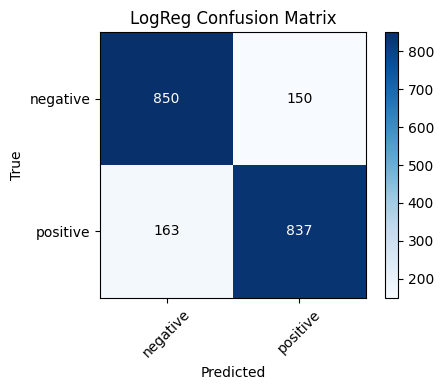


=== NaiveBayes ===
Accuracy: 0.852
              precision    recall  f1-score   support

    negative       0.86      0.84      0.85      1000
    positive       0.85      0.86      0.85      1000

    accuracy                           0.85      2000
   macro avg       0.85      0.85      0.85      2000
weighted avg       0.85      0.85      0.85      2000



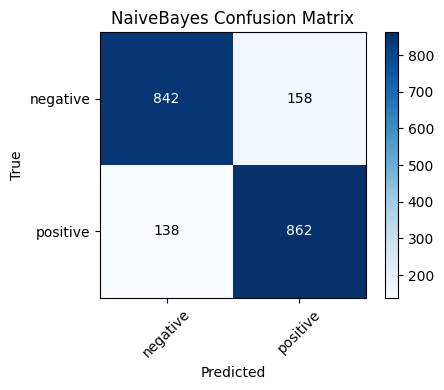

In [ ]:
#@title  Evaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt, numpy as np, itertools
def plot_cm(y_true, y_pred, title='Confusion Matrix'):
    cm = confusion_matrix(y_true, y_pred, labels=['negative','positive'])
    classes = ['negative','positive']
    plt.figure(figsize=(5,4))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title(title); plt.colorbar()
    ticks = np.arange(len(classes))
    plt.xticks(ticks, classes, rotation=45); plt.yticks(ticks, classes)
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], 'd'), ha='center', va='center',
                 color='white' if cm[i, j] > cm.max()/2 else 'black')
    plt.ylabel('True'); plt.xlabel('Predicted'); plt.tight_layout(); plt.show()
for name, clf in [('LogReg', logreg), ('NaiveBayes', nb)]:
    preds = clf.predict(Xte)
    print(f"\n=== {name} ==="); print('Accuracy:', accuracy_score(y_test, preds))
    print(classification_report(y_test, preds)); plot_cm(y_test, preds, f'{name} Confusion Matrix')

##  Reflections: Error Analysis Hook
Run this right after you compute predictions to get structured reflections and quick rules.


In [ ]:
# Reflection Box — Reflections: Error Analysis Hook
try:
    import ipywidgets as widgets
    from IPython.display import display, clear_output
    _ref_input_10 = widgets.Textarea(
        description='Reflection:',
        placeholder='Write a short reflection about this step...',
        layout=widgets.Layout(width='100%', height='120px')
    )
    _submit_10 = widgets.Button(description='Submit Reflection')
    _msg_10 = widgets.Output()
    def _on_submit_10(b):
        with _msg_10:
            clear_output(wait=True)
            uid = _get_user_id() if ' _get_user_id' or '_get_user_id' in globals() else 'anonymous'
            ok, msg = append_reflection_row('Reflections: Error Analysis Hook'.strip(), uid, _ref_input_10.value.strip())
            if ok:
                print('Saved.')
                _ref_input_10.value = ''
            else:
                print(msg)
    _submit_10.on_click(_on_submit_10)
    display(_ref_input_10, _submit_10, _msg_10)
except Exception as e:
    print('Reflection box unavailable:', e)

In [ ]:
# --- After predictions are computed, map your variables here ---
# Expected: y_test (labels) if available, y_pred (predictions), X_test_text (texts)
X_test_text = globals().get('X_test_text', globals().get('texts_test', None))
y_pred = globals().get('y_pred', None)
y_test = globals().get('y_test', None)
assert X_test_text is not None and y_pred is not None, 'Please define X_test_text and y_pred before running reflections.'

df_reflections = run_reflections(texts=list(X_test_text), preds=list(y_pred), labels=list(y_test) if y_test is not None else None)


try:
    import matplotlib.pyplot as plt
    vc = df_reflections['action'].value_counts().head(10)
    plt.figure()
    vc.plot(kind='bar')
    plt.title('Top Reflection Actions')
    plt.xlabel('Action')
    plt.ylabel('Count')
    plt.show()
except Exception as e:
    print('Plot skipped:', e)

USER_ID = _get_user_id()



##  Reflections: Rule-Based Revision (Optional)
Apply simple rules inferred from reflections to produce revised predictions for analysis.


##  Evaluation: Before vs After Reflections (Optional)
Compare metrics using original predictions vs. rule-revised predictions.


In [1]:
# Reflection Box — Evaluation: Before vs After Reflections (Optional)
try:
    import ipywidgets as widgets
    from IPython.display import display, clear_output
    _ref_input_12 = widgets.Textarea(
        description='Reflection:',
        placeholder='Write a short reflection about this step...',
        layout=widgets.Layout(width='100%', height='120px')
    )
    _submit_12 = widgets.Button(description='Submit Reflection')
    _msg_12 = widgets.Output()
    def _on_submit_12(b):
        with _msg_12:
            clear_output(wait=True)
            uid = _get_user_id() if ' _get_user_id' or '_get_user_id' in globals() else 'anonymous'
            ok, msg = append_reflection_row('Evaluation: Before vs After Reflections (Optional)'.strip(), uid, _ref_input_12.value.strip())
            if ok:
                print('Saved.')
                _ref_input_12.value = ''
            else:
                print(msg)
    _submit_12.on_click(_on_submit_12)
    display(_ref_input_12, _submit_12, _msg_12)
except Exception as e:
    print('Reflection box unavailable:', e)

Textarea(value='', description='Reflection:', layout=Layout(height='120px', width='100%'), placeholder='Write …

Button(description='Submit Reflection', style=ButtonStyle())

Output()

##  Reflections: Data Augmentation from Errors (Optional)
Generate simple counterfactuals informed by reflections and add them to the training set.


## 7) Try it

In [ ]:
# Reflection Box — 7) Try it
try:
    import ipywidgets as widgets
    from IPython.display import display, clear_output
    _ref_input_14 = widgets.Textarea(
        description='Reflection:',
        placeholder='Write a short reflection about this step...',
        layout=widgets.Layout(width='100%', height='120px')
    )
    _submit_14 = widgets.Button(description='Submit Reflection')
    _msg_14 = widgets.Output()
    def _on_submit_14(b):
        with _msg_14:
            clear_output(wait=True)
            uid = _get_user_id() if ' _get_user_id' or '_get_user_id' in globals() else 'anonymous'
            ok, msg = append_reflection_row('7) Try it'.strip(), uid, _ref_input_14.value.strip())
            if ok:
                print('Saved.')
                _ref_input_14.value = ''
            else:
                print(msg)
    _submit_14.on_click(_on_submit_14)
    display(_ref_input_14, _submit_14, _msg_14)
except Exception as e:
    print('Reflection box unavailable:', e)

In [ ]:
#@title ️ Predict your own review
import ipywidgets as widgets
from IPython.display import display
box = widgets.Textarea(placeholder='Type a short Yelp-style review...')
btn = widgets.Button(description='Predict')
out = widgets.Output()
def go(_):
    Xq = tfidf.transform([box.value])
    p1 = logreg.predict(Xq)[0]; p2 = nb.predict(Xq)[0]
    with out:
        out.clear_output(); print('LogReg:', p1, '| NaiveBayes:', p2)
btn.on_click(go); display(box, btn, out)

Textarea(value='', placeholder='Type a short Yelp-style review...')

Button(description='Predict', style=ButtonStyle())

Output()

## 8) Save best model

## Reflections System (imported)

> This section was imported from the Workshop notebook and lightly wrapped for use in the Yelp review workflow.


In [ ]:
# Reflection Box — Reflections System (imported)
try:
    import ipywidgets as widgets
    from IPython.display import display, clear_output
    _ref_input_16 = widgets.Textarea(
        description='Reflection:',
        placeholder='Write a short reflection about this step...',
        layout=widgets.Layout(width='100%', height='120px')
    )
    _submit_16 = widgets.Button(description='Submit Reflection')
    _msg_16 = widgets.Output()
    def _on_submit_16(b):
        with _msg_16:
            clear_output(wait=True)
            uid = _get_user_id() if ' _get_user_id' or '_get_user_id' in globals() else 'anonymous'
            ok, msg = append_reflection_row('Reflections System (imported)'.strip(), uid, _ref_input_16.value.strip())
            if ok:
                print('Saved.')
                _ref_input_16.value = ''
            else:
                print(msg)
    _submit_16.on_click(_on_submit_16)
    display(_ref_input_16, _submit_16, _msg_16)
except Exception as e:
    print('Reflection box unavailable:', e)

> Note: If the Reflections code expects variables from the Workshop notebook (e.g., `predictions`, `texts`, or a model client),
> map them to the Yelp variables here before running. For example:
>
> ```python
# predictions_yelp = model.predict(yelp_texts)
# reflections = run_reflections(texts=yelp_texts, preds=predictions_yelp)
> ```


In [ ]:
#@title Mini-Quiz
# Requires: run the "Classroom helpers (run once)" cell at the top.
try:
    make_quiz_mc(
        "Which of these words is more formal?",
        ["Therefore", "Rizz", "Skibidi"],
        0
    )
    make_quiz_mc(
        "Which of these is slang?",
        ["However", "Nevertheless", "Sus"],
        2
    )
except NameError:
    print("️ Please run the 'Classroom helpers (run once)' cell at the top, then re-run this cell.")
